<a href="https://colab.research.google.com/github/urvi1703/AI-Sign-Language-Interpreter-Streamlit-Deep-Learning-MediaPipe-/blob/main/Sign_Language_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mediapipe opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14

Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.2

In [ ]:
import mediapipe as mp

print(mp.__version__)

mp_hands = mp.solutions.hands
print("MediaPipe loaded successfully!")

0.10.14
MediaPipe loaded successfully!


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dorukdemirci/asl-alphabet-dataset")

print("Path to dataset files:", path)

100%|██████████| 14.4M/14.4M [00:00<00:00, 77.1MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dorukdemirci/asl-alphabet-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['dataset']


In [ ]:
import os

print("Main folders:", os.listdir(path))

Main folders: ['dataset']


In [ ]:
dataset_path = os.path.join(path, "dataset")
print(os.listdir(dataset_path))

['W-samples', 'A-samples', 'F-samples', 'E-samples', 'L-samples', 'S-samples', 'Y-samples', 'G-samples', 'U-samples', 'H-samples', 'X-samples', 'Q-samples', 'M-samples', 'D-samples', 'O-samples', 'B-samples', 'C-samples', 'V-samples', 'K-samples', 'I-samples', 'R-samples', 'T-samples', 'N-samples', 'P-samples']


Total classes: 24
Image path: /root/.cache/kagglehub/datasets/dorukdemirci/asl-alphabet-dataset/versions/1/dataset/H-samples/77.jpg


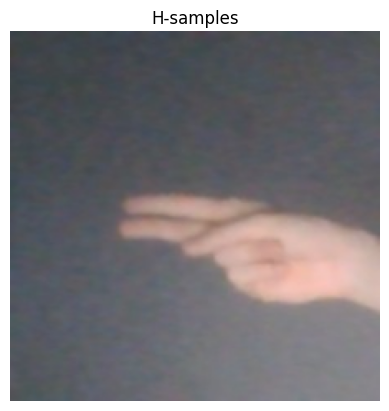

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

dataset_path = os.path.join(path, "dataset")

classes = os.listdir(dataset_path)
print("Total classes:", len(classes))

random_class = random.choice(classes)

img_folder = os.path.join(dataset_path, random_class)
img_name = random.choice(os.listdir(img_folder))

img_path = os.path.join(img_folder, img_name)
print("Image path:", img_path)

img = cv2.imread(img_path)

if img is None:
    print("Image not loaded!")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(random_class)
    plt.axis("off")

In [ ]:
import mediapipe as mp

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True)
mp_draw = mp.solutions.drawing_utils

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = hands.process(img_rgb)

if results.multi_hand_landmarks:
    for hand_landmarks in results.multi_hand_landmarks:
        mp_draw.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    plt.imshow(img)
    plt.title("Hand Landmarks")
    plt.axis("off")
else:
    print("No hand detected")

No hand detected


Hand detected in: /root/.cache/kagglehub/datasets/dorukdemirci/asl-alphabet-dataset/versions/1/dataset/G-samples/94.jpg


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


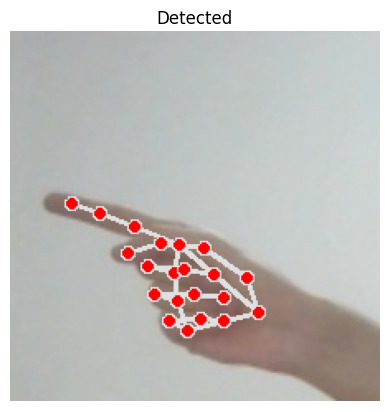

In [ ]:
for i in range(10):
    random_class = random.choice(classes)

    img_folder = os.path.join(dataset_path, random_class)
    img_name = random.choice(os.listdir(img_folder))
    img_path = os.path.join(img_folder, img_name)

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = hands.process(img_rgb)

    if results.multi_hand_landmarks:
        print("Hand detected in:", img_path)

        for hand_landmarks in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Detected")
        plt.axis("off")
        break

In [ ]:
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.3
)

In [ ]:
# Improve detection
img_resized = cv2.resize(img, (256, 256))

# Optional: increase contrast
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
img_enhanced = cv2.equalizeHist(img_gray)
img_enhanced = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2BGR)

img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.2
)

results = hands.process(img_rgb)

if results.multi_hand_landmarks:
    print("Hand detected after preprocessing!")

    for hand_landmarks in results.multi_hand_landmarks:
        mp_draw.draw_landmarks(img_resized, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.axis("off")
else:
    print("Still no hand detected")

Still no hand detected


In [ ]:
X = []
y = []

label_map = {}

classes = os.listdir(dataset_path)

for idx, class_name in enumerate(classes):
    label_map[idx] = class_name

    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    print("Processing:", class_name)

    for img_name in images[:200]:  # limit for faster testing
        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, (256, 256))

        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        img_enhanced = cv2.equalizeHist(img_gray)
        img_enhanced = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2BGR)

        img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)

        results = hands.process(img_rgb)

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                landmark_list = []

                for lm in hand_landmarks.landmark:
                    landmark_list.append(lm.x)
                    landmark_list.append(lm.y)
                    landmark_list.append(lm.z)

                X.append(landmark_list)
                y.append(idx)

Processing: W-samples
Processing: A-samples
Processing: F-samples
Processing: E-samples
Processing: L-samples
Processing: S-samples
Processing: Y-samples
Processing: G-samples
Processing: U-samples
Processing: H-samples
Processing: X-samples
Processing: Q-samples
Processing: M-samples
Processing: D-samples
Processing: O-samples
Processing: B-samples
Processing: C-samples
Processing: V-samples
Processing: K-samples
Processing: I-samples
Processing: R-samples
Processing: T-samples
Processing: N-samples
Processing: P-samples


In [ ]:
print(len(X), "samples extracted")

94 samples extracted


In [ ]:
X = []
y = []

label_map = {}

classes = os.listdir(dataset_path)

total = 0
detected = 0

for idx, class_name in enumerate(classes):
    label_map[idx] = class_name

    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    print("Processing:", class_name)

    for img_name in images[:200]:
        total += 1

        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_resized = cv2.resize(img, (256, 256))

        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        results = hands.process(img_rgb)

        if results.multi_hand_landmarks:
            detected += 1

            for hand_landmarks in results.multi_hand_landmarks:
                landmark_list = []

                for lm in hand_landmarks.landmark:
                    landmark_list.append(lm.x)
                    landmark_list.append(lm.y)
                    landmark_list.append(lm.z)

                X.append(landmark_list)
                y.append(idx)

print("Total images:", total)
print("Hands detected:", detected)

Processing: W-samples
Processing: A-samples
Processing: F-samples
Processing: E-samples
Processing: L-samples
Processing: S-samples
Processing: Y-samples
Processing: G-samples
Processing: U-samples
Processing: H-samples
Processing: X-samples
Processing: Q-samples
Processing: M-samples
Processing: D-samples
Processing: O-samples
Processing: B-samples
Processing: C-samples
Processing: V-samples
Processing: K-samples
Processing: I-samples
Processing: R-samples
Processing: T-samples
Processing: N-samples
Processing: P-samples
Total images: 2427
Hands detected: 2393


In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2393, 63)
Shape of y: (2393,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1914, 63) (479, 63)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9874739039665971


In [ ]:
import pandas as pd

y_series = pd.Series(y)
print(y_series.value_counts())

2     102
16    102
13    102
10    102
15    101
1     101
3     101
7     101
18    101
11    101
4     100
0     100
22    100
6     100
21    100
19    100
5      99
17     99
9      99
20     98
14     97
23     97
12     96
8      94
Name: count, dtype: int64


In [ ]:
import numpy as np

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(100), np.int64(1): np.int64(101), np.int64(2): np.int64(102), np.int64(3): np.int64(101), np.int64(4): np.int64(100), np.int64(5): np.int64(99), np.int64(6): np.int64(100), np.int64(7): np.int64(101), np.int64(8): np.int64(94), np.int64(9): np.int64(99), np.int64(10): np.int64(102), np.int64(11): np.int64(101), np.int64(12): np.int64(96), np.int64(13): np.int64(102), np.int64(14): np.int64(97), np.int64(15): np.int64(101), np.int64(16): np.int64(102), np.int64(17): np.int64(99), np.int64(18): np.int64(101), np.int64(19): np.int64(100), np.int64(20): np.int64(98), np.int64(21): np.int64(100), np.int64(22): np.int64(100), np.int64(23): np.int64(97)}


In [ ]:
import pandas as pd

y_series = pd.Series(y)
print(y_series.value_counts())

2     102
16    102
13    102
10    102
15    101
1     101
3     101
7     101
18    101
11    101
4     100
0     100
22    100
6     100
21    100
19    100
5      99
17     99
9      99
20     98
14     97
23     97
12     96
8      94
Name: count, dtype: int64


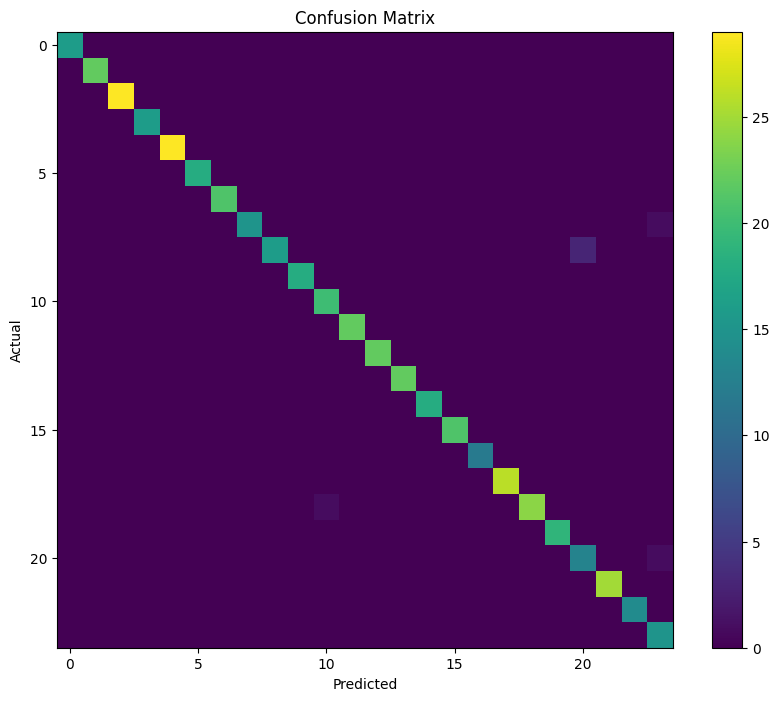

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pickle

with open("asl_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!


In [ ]:
pip install streamlit opencv-python mediapipe numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 59.2 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [24]:
import pickle

with open("asl_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [25]:
from google.colab import files
files.download("asl_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>